# EEG Pipeline v2 — Flow State & Resilience Analysis
**Master's Thesis:** Ykylas Nurkhan, KBTU

**Dataset:** COG-BCI (Hinss et al., 2023) — 29 participants, 3 sessions

**Changes from v1:**
1. ICA artifact rejection (eye blinks + muscle)
2. ROI-based analysis (frontal θ, parietal α, frontal β)
3. θ/β ratio (frontal)
4. ROI-based α/β ratio = parietal α / frontal β
5. Duplicate subject verification
6. Complete N=29 analysis

## Step 0: Install & Import

In [ ]:
!pip install -q mne

import os
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import welch
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from mne.preprocessing import ICA
from pathlib import Path
import warnings
import gc
import time
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(f'MNE version: {mne.__version__}')
print('Pipeline v2 ready ✓')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 36.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
MNE version: 1.12.0
Pipeline v2 ready ✓


## Step 1: Download all 29 subjects from Zenodo
Each subject is ~1GB. Total ~29GB. This will take a while.

In [ ]:
!mkdir -p data

BASE_URL = 'https://zenodo.org/records/6874129/files'
SUBJECTS = [f'sub-{i:02d}' for i in range(1, 30)]

for sub in SUBJECTS:
    zip_path = f'data/{sub}.zip'
    extracted_dir = f'data/{sub}'

    # Skip if already extracted
    if os.path.isdir(extracted_dir):
        n_files = len(list(Path(extracted_dir).glob('**/*.set')))
        if n_files >= 30:  # expect ~36 .set files
            print(f'{sub}: already extracted ({n_files} .set files) ✓')
            continue

    print(f'\nDownloading {sub}...')
    # Download with retry
    for attempt in range(3):
        ret = os.system(f'wget -q -P data -nc {BASE_URL}/{sub}.zip')
        if ret == 0:
            break
        print(f'  Retry {attempt+1}...')
        time.sleep(5)

    # Unzip
    print(f'  Extracting...')
    os.system(f'cd data && unzip -o -q {sub}.zip')

    # Verify
    n_files = len(list(Path(extracted_dir).glob('**/*.set')))
    print(f'  {sub}: {n_files} .set files')

    # Remove zip to save space
    if os.path.exists(zip_path):
        os.remove(zip_path)
        print(f'  Removed zip to save space')

print('\n' + '='*50)
print('Download complete!')


  Extracting...
  sub-01: 36 .set files
  Removed zip to save space

  Extracting...
  sub-02: 36 .set files
  Removed zip to save space

  Extracting...
  sub-03: 36 .set files
  Removed zip to save space

  Extracting...
  sub-04: 36 .set files
  Removed zip to save space

  Extracting...
  sub-05: 36 .set files
  Removed zip to save space

  Extracting...
  sub-06: 36 .set files
  Removed zip to save space

  Extracting...
  sub-07: 36 .set files
  Removed zip to save space

  Extracting...
  sub-08: 36 .set files
  Removed zip to save space

  Extracting...
  sub-09: 36 .set files
  Removed zip to save space

  Extracting...
  sub-10: 36 .set files
  Removed zip to save space

  Extracting...
  sub-11: 36 .set files
  Removed zip to save space

  Extracting...
  sub-12: 36 .set files
  Removed zip to save space

  Extracting...
  sub-13: 36 .set files
  Removed zip to save space

  Extracting...
  sub-14: 36 .set files
  Removed zip to save space

  Extracting...
  sub-15: 36 .set

In [ ]:
import shutil

# Subjects to re-download
bad_subs = ['sub-17','sub-18','sub-19','sub-20','sub-21','sub-22',
            'sub-23','sub-24','sub-25','sub-27','sub-28']

for sub in bad_subs:
    path = f'data/{sub}'
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f'Deleted {path}')

    zip_path = f'data/{sub}.zip'
    if os.path.exists(zip_path):
        os.remove(zip_path)

    print(f'Downloading {sub}...')
    # Download with wget -c for resume support
    ret = os.system(f'wget -c -P data {BASE_URL}/{sub}.zip')
    if ret != 0:
        print(f'  ⚠️ Failed, retrying...')
        time.sleep(10)
        os.system(f'wget -c -P data {BASE_URL}/{sub}.zip')

    os.system(f'cd data && unzip -o -q {sub}.zip')
    n = len(list(Path(f'data/{sub}').glob('**/*.set')))
    print(f'  {sub}: {n} .set files')

    # Remove zip
    if os.path.exists(zip_path):
        os.remove(zip_path)

print('\nDone! Run Step 2 (verification) again.')

Deleted data/sub-17
  sub-17: 36 .set files
Deleted data/sub-18
  sub-18: 36 .set files
Deleted data/sub-19
  sub-19: 36 .set files
Deleted data/sub-20
  sub-20: 36 .set files
Deleted data/sub-21
  sub-21: 36 .set files
Deleted data/sub-22
  sub-22: 36 .set files
Deleted data/sub-23
  sub-23: 36 .set files
Deleted data/sub-24
  sub-24: 36 .set files
Deleted data/sub-25
  sub-25: 36 .set files
Deleted data/sub-27
  sub-27: 36 .set files
Deleted data/sub-28
  sub-28: 36 .set files

Done! Run Step 2 (verification) again.


In [ ]:
# Check which subjects are real and which are duplicates
import os
from pathlib import Path

for sub in [f'sub-{i:02d}' for i in range(1, 30)]:
    path = Path(f'data/{sub}')
    if path.exists():
        set_files = list(path.glob('**/*.set'))
        # Get total size of all .set + .fdt files
        total_size = sum(f.stat().st_size for f in path.glob('**/*') if f.is_file())
        print(f'{sub}: {len(set_files)} files, {total_size/1e9:.2f} GB')
    else:
        print(f'{sub}: NOT FOUND')

sub-01: 36 files, 1.35 GB
sub-02: 36 files, 1.33 GB
sub-03: 36 files, 1.33 GB
sub-04: 36 files, 1.32 GB
sub-05: 36 files, 1.32 GB
sub-06: 36 files, 1.30 GB
sub-07: 36 files, 1.31 GB
sub-08: 36 files, 1.31 GB
sub-09: 36 files, 1.32 GB
sub-10: 36 files, 1.34 GB
sub-11: 36 files, 1.35 GB
sub-12: 36 files, 1.33 GB
sub-13: 36 files, 1.33 GB
sub-14: 36 files, 1.34 GB
sub-15: 36 files, 1.32 GB
sub-16: 36 files, 1.31 GB
sub-17: 36 files, 1.32 GB
sub-18: 36 files, 1.32 GB
sub-19: 36 files, 1.32 GB
sub-20: 36 files, 1.32 GB
sub-21: 36 files, 1.32 GB
sub-22: 36 files, 1.32 GB
sub-23: 36 files, 1.32 GB
sub-24: 36 files, 1.32 GB
sub-25: 36 files, 1.33 GB
sub-26: 36 files, 1.34 GB
sub-27: 36 files, 1.32 GB
sub-28: 36 files, 1.33 GB
sub-29: 36 files, 1.31 GB


## Step 2: Verify — no duplicates

In [ ]:
# Better duplicate check — compare more data points
import hashlib

fingerprints = {}

for sub in [f'sub-{i:02d}' for i in range(1, 30)]:
    set_files = sorted(Path(f'data/{sub}').glob('**/*.set'))
    if not set_files:
        continue

    try:
        raw = mne.io.read_raw_eeglab(str(set_files[0]), preload=True, verbose=False)
        data = raw.get_data()
        # Use hash of first 10000 data points as fingerprint
        fp = hashlib.md5(data[:, :10000].tobytes()).hexdigest()
        fingerprints[sub] = fp
        del raw, data
        gc.collect()
    except Exception as e:
        print(f'{sub}: Error — {e}')

# Check duplicates
from collections import defaultdict
groups = defaultdict(list)
for sub, fp in fingerprints.items():
    groups[fp].append(sub)

has_dupes = False
for fp, subs in groups.items():
    if len(subs) > 1:
        print(f'⚠️  DUPLICATE GROUP: {subs}')
        has_dupes = True

if not has_dupes:
    print(f'✓ All {len(fingerprints)} subjects are unique!')

⚠️  DUPLICATE GROUP: ['sub-17', 'sub-18', 'sub-19', 'sub-20', 'sub-21', 'sub-22', 'sub-23', 'sub-24', 'sub-27']
⚠️  DUPLICATE GROUP: ['sub-25', 'sub-28']


In [ ]:
# Define valid subjects
DUPLICATE_SUBS = {'sub-18','sub-19','sub-20','sub-21','sub-22',
                  'sub-23','sub-24','sub-27','sub-28'}

VALID_SUBJECTS = [s for s in SUBJECTS if s not in DUPLICATE_SUBS]
print(f'Valid unique subjects: {len(VALID_SUBJECTS)}')
print(VALID_SUBJECTS)

# Update the processing list
subjects_to_process = VALID_SUBJECTS

Valid unique subjects: 20
['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10', 'sub-11', 'sub-12', 'sub-13', 'sub-14', 'sub-15', 'sub-16', 'sub-17', 'sub-25', 'sub-26', 'sub-29']


## Step 3: Configuration

In [ ]:
# ---- Frequency bands ----
BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 45)
}

# ---- ROI channel groups ----
ROIS = {
    'frontal':  ['Fz', 'F3', 'F4', 'FCz'],  # theta + beta source
    'parietal': ['Pz', 'P3', 'P4'],           # alpha source
}

# ---- Workload mapping ----
def assign_workload(filename):
    fname = filename.lower()
    if 'zeroback' in fname or 'matbeasy' in fname:
        return 'Low'
    elif 'oneback' in fname or 'matbmed' in fname or 'flanker' in fname:
        return 'Medium'
    elif 'twoback' in fname or 'matbdiff' in fname:
        return 'High'
    elif 'pvt' in fname:
        return 'Low-Medium'
    elif 'rs_' in fname:
        return 'Resting'
    return 'Unknown'

def assign_task(filename):
    fname = filename.lower()
    if 'back' in fname: return 'N-Back'
    elif 'matb' in fname: return 'MATB'
    elif 'flanker' in fname: return 'Flanker'
    elif 'pvt' in fname: return 'PVT'
    elif 'rs_' in fname: return 'Resting'
    return 'Unknown'

def assign_resting_type(filename):
    """Classify resting state files for NRI computation."""
    fname = filename.lower()
    if 'rs_beg_ec' in fname or 'rs_beg_ec' in fname: return 'pre_EC'
    if 'rs_beg_eo' in fname: return 'pre_EO'
    if 'rs_end_ec' in fname or 'rs_end_ec' in fname: return 'post_EC'
    if 'rs_end_eo' in fname: return 'post_EO'
    return None

EPOCH_LEN_SEC = 30

print('Configuration ✓')
print(f'ROIs: {list(ROIS.keys())}')
print(f'Bands: {list(BANDS.keys())}')
print(f'Epoch length: {EPOCH_LEN_SEC}s')

Configuration ✓
ROIs: ['frontal', 'parietal']
Bands: ['delta', 'theta', 'alpha', 'beta', 'gamma']
Epoch length: 30s


## Step 4: Helper Functions

In [ ]:
def compute_band_power(data, sfreq, band, nperseg=None):
    """
    Compute average power in a frequency band using Welch's PSD.
    data: 1D or 2D (channels x samples)
    """
    if nperseg is None:
        nperseg = int(2 * sfreq)  # 2-second windows

    if data.ndim == 1:
        data = data.reshape(1, -1)

    powers = []
    for ch in range(data.shape[0]):
        freqs, psd = welch(data[ch], fs=sfreq, nperseg=nperseg, noverlap=nperseg//2)
        idx = np.where((freqs >= band[0]) & (freqs <= band[1]))[0]
        if len(idx) > 0:
            band_power = np.trapz(psd[idx], freqs[idx])
            powers.append(band_power)

    return np.mean(powers) if powers else 0.0


def compute_roi_features(data_dict, sfreq):
    """
    Compute ROI-based features from channel-grouped data.

    data_dict: {'frontal': ndarray, 'parietal': ndarray}
    Returns dict with all metrics.
    """
    features = {}

    # --- Frontal ROI ---
    frontal_data = data_dict.get('frontal')
    if frontal_data is not None and frontal_data.size > 0:
        features['frontal_theta'] = compute_band_power(frontal_data, sfreq, BANDS['theta'])
        features['frontal_alpha'] = compute_band_power(frontal_data, sfreq, BANDS['alpha'])
        features['frontal_beta']  = compute_band_power(frontal_data, sfreq, BANDS['beta'])
        features['frontal_delta'] = compute_band_power(frontal_data, sfreq, BANDS['delta'])
        features['frontal_gamma'] = compute_band_power(frontal_data, sfreq, BANDS['gamma'])

    # --- Parietal ROI ---
    parietal_data = data_dict.get('parietal')
    if parietal_data is not None and parietal_data.size > 0:
        features['parietal_theta'] = compute_band_power(parietal_data, sfreq, BANDS['theta'])
        features['parietal_alpha'] = compute_band_power(parietal_data, sfreq, BANDS['alpha'])
        features['parietal_beta']  = compute_band_power(parietal_data, sfreq, BANDS['beta'])

    # --- Global (all channels, for comparison with v1) ---
    all_data = np.concatenate([v for v in data_dict.values() if v is not None and v.size > 0], axis=0)
    features['global_alpha'] = compute_band_power(all_data, sfreq, BANDS['alpha'])
    features['global_beta']  = compute_band_power(all_data, sfreq, BANDS['beta'])
    features['global_theta'] = compute_band_power(all_data, sfreq, BANDS['theta'])

    # --- Derived ratios ---
    fb = features.get('frontal_beta', 0)
    pa = features.get('parietal_alpha', 0)
    ft = features.get('frontal_theta', 0)
    ga = features.get('global_alpha', 0)
    gb = features.get('global_beta', 0)

    # ROI-based α/β (parietal alpha / frontal beta) — main metric
    features['roi_ab_ratio'] = pa / fb if fb > 0 else 0

    # θ/β ratio (frontal theta / frontal beta) — attention index
    features['theta_beta_ratio'] = ft / fb if fb > 0 else 0

    # Global α/β (for backward compatibility with v1)
    features['global_ab_ratio'] = ga / gb if gb > 0 else 0

    # Alpha proportions
    total_roi = pa + fb
    features['roi_alpha_rel'] = pa / total_roi if total_roi > 0 else 0
    features['roi_beta_rel']  = fb / total_roi if total_roi > 0 else 0

    total_global = ga + gb
    features['global_alpha_rel'] = ga / total_global if total_global > 0 else 0
    features['global_beta_rel']  = gb / total_global if total_global > 0 else 0

    return features


def get_roi_picks(raw, roi_channels):
    """
    Get channel indices for ROI, handling missing channels gracefully.
    """
    available = raw.ch_names
    picks = [available.index(ch) for ch in roi_channels if ch in available]
    found = [ch for ch in roi_channels if ch in available]
    missing = [ch for ch in roi_channels if ch not in available]
    if missing:
        print(f'    ⚠️  Missing channels: {missing}')
    return picks, found


print('Helper functions defined ✓')

Helper functions defined ✓


## Step 5: Process All Subjects
This is the main loop. For each subject:
1. Load each .set file
2. Bandpass filter 1-45 Hz
3. Run ICA → auto-detect and remove eye/muscle artifacts
4. Extract ROI channels
5. Segment into 30s epochs
6. Compute ROI-based features

**Expected time: ~2-3 hours for all 29 subjects on Colab.**

In [ ]:
data_dir = Path('data')
all_results = []
all_resting = []
processing_log = []

subjects_to_process = VALID_SUBJECTS  # 20 unique

for sub_idx, sub in enumerate(subjects_to_process):
    print(f'\n{"="*60}')
    print(f'[{sub_idx+1}/{len(subjects_to_process)}] Processing {sub}')
    print(f'{"="*60}')

    set_files = sorted(data_dir.glob(f'{sub}/**/eeg/*.set'))

    if not set_files:
        print(f'  ⚠️  No .set files found, skipping')
        processing_log.append({'subject': sub, 'status': 'no_files', 'n_files': 0})
        continue

    print(f'  Found {len(set_files)} files')
    sub_start = time.time()
    files_processed = 0
    files_failed = 0

    for set_file in set_files:
        filename = set_file.stem
        session = set_file.parts[-3]  # ses-S1, ses-S2, ses-S3
        task = assign_task(filename)
        workload = assign_workload(filename)
        resting_type = assign_resting_type(filename)

        try:
            # ---- Load ----
            raw = mne.io.read_raw_eeglab(str(set_file), preload=True, verbose=False)
            sfreq = raw.info['sfreq']

            # ---- Bandpass filter 1-45 Hz ----
            raw.filter(l_freq=1, h_freq=45, verbose=False)

            # ---- ICA artifact rejection ----
            # Fit ICA
            n_components = min(20, len(raw.ch_names) - 1)
            ica = ICA(n_components=n_components, method='fastica',
                      random_state=42, max_iter=500)
            ica.fit(raw, verbose=False)

            # Auto-detect bad components
            bad_components = []

            # Eye blink artifacts (EOG)
            # Use frontal channels as EOG proxy if no dedicated EOG channel
            try:
                eog_indices, eog_scores = ica.find_bads_eog(
                    raw, ch_name=['Fp1', 'Fp2'], verbose=False)
                bad_components.extend(eog_indices)
            except:
                try:
                    eog_indices, eog_scores = ica.find_bads_eog(
                        raw, verbose=False)
                    bad_components.extend(eog_indices)
                except:
                    pass  # No EOG detection possible

            # Muscle artifacts
            try:
                muscle_indices, muscle_scores = ica.find_bads_muscle(
                    raw, verbose=False)
                bad_components.extend(muscle_indices)
            except:
                pass  # Some MNE versions don't support this

            # Remove duplicates and apply
            ica.exclude = list(set(bad_components))
            n_removed = len(ica.exclude)
            ica.apply(raw, verbose=False)

            # ---- Get ROI channel data ----
            roi_data = {}
            for roi_name, roi_channels in ROIS.items():
                picks, found_chs = get_roi_picks(raw, roi_channels)
                if picks:
                    roi_data[roi_name] = raw.get_data(picks=picks)
                else:
                    roi_data[roi_name] = None

            # ---- Segment into epochs ----
            total_samples = raw.n_times
            epoch_samples = int(EPOCH_LEN_SEC * sfreq)
            n_epochs = total_samples // epoch_samples

            for ep in range(n_epochs):
                start = ep * epoch_samples
                end = start + epoch_samples

                # Slice each ROI
                epoch_roi_data = {}
                for roi_name, data in roi_data.items():
                    if data is not None:
                        epoch_roi_data[roi_name] = data[:, start:end]

                # Compute features
                features = compute_roi_features(epoch_roi_data, sfreq)

                # Add metadata
                features['subject'] = sub
                features['session'] = session
                features['task'] = task
                features['workload'] = workload
                features['epoch'] = ep
                features['filename'] = filename
                features['ica_components_removed'] = n_removed

                # Store in appropriate list
                if resting_type:
                    features['resting_type'] = resting_type
                    all_resting.append(features)
                else:
                    all_results.append(features)

            files_processed += 1

            # Free memory
            del raw, ica, roi_data
            gc.collect()

        except Exception as e:
            print(f'    ⚠️  Error in {filename}: {e}')
            files_failed += 1
            continue

    elapsed = time.time() - sub_start
    print(f'  Done: {files_processed} files, {files_failed} failed, {elapsed:.0f}s')
    processing_log.append({
        'subject': sub, 'status': 'ok',
        'n_files': files_processed, 'n_failed': files_failed,
        'time_sec': elapsed
    })

# Convert to DataFrames
df = pd.DataFrame(all_results)
df_rest = pd.DataFrame(all_resting)
df_log = pd.DataFrame(processing_log)

print(f'\n{"="*60}')
print(f'PROCESSING COMPLETE')
print(f'{"="*60}')
print(f'Task epochs: {len(df)}')
print(f'Resting epochs: {len(df_rest)}')
print(f'Subjects processed: {len(df_log[df_log["status"]=="ok"])}')


[1/20] Processing sub-01
  Found 36 files
  Done: 36 files, 0 failed, 637s

[2/20] Processing sub-02
  Found 36 files
  Done: 36 files, 0 failed, 673s

[3/20] Processing sub-03
  Found 36 files
  Done: 36 files, 0 failed, 920s

[4/20] Processing sub-04
  Found 36 files
  Done: 36 files, 0 failed, 647s

[5/20] Processing sub-05
  Found 36 files
  Done: 36 files, 0 failed, 763s

[6/20] Processing sub-06
  Found 36 files
  Done: 36 files, 0 failed, 647s

[7/20] Processing sub-07
  Found 36 files
  Done: 36 files, 0 failed, 741s

[8/20] Processing sub-08
  Found 36 files
  Done: 36 files, 0 failed, 632s

[9/20] Processing sub-09
  Found 36 files
  Done: 36 files, 0 failed, 678s

[10/20] Processing sub-10
  Found 36 files
  Done: 36 files, 0 failed, 692s

[11/20] Processing sub-11
  Found 36 files
  Done: 36 files, 0 failed, 592s

[12/20] Processing sub-12
  Found 36 files
  Done: 36 files, 0 failed, 607s

[13/20] Processing sub-13
  Found 36 files
  Done: 36 files, 0 failed, 702s

[14/20]

## Step 6: Save Raw Results

In [ ]:
# Save everything
df.to_csv('v2_all_epochs.csv', index=False)
df_rest.to_csv('v2_all_resting.csv', index=False)
df_log.to_csv('v2_processing_log.csv', index=False)

print(f'Saved v2_all_epochs.csv ({len(df)} rows)')
print(f'Saved v2_all_resting.csv ({len(df_rest)} rows)')
print(f'Saved v2_processing_log.csv ({len(df_log)} rows)')

# Quick sanity check
print(f'\nColumns in task data: {list(df.columns)}')
print(f'\nWorkload distribution:')
print(df['workload'].value_counts())
print(f'\nTask distribution:')
print(df['task'].value_counts())

Saved v2_all_epochs.csv (5974 rows)
Saved v2_all_resting.csv (433 rows)
Saved v2_processing_log.csv (20 rows)

Columns in task data: ['frontal_theta', 'frontal_alpha', 'frontal_beta', 'frontal_delta', 'frontal_gamma', 'parietal_theta', 'parietal_alpha', 'parietal_beta', 'global_alpha', 'global_beta', 'global_theta', 'roi_ab_ratio', 'theta_beta_ratio', 'global_ab_ratio', 'roi_alpha_rel', 'roi_beta_rel', 'global_alpha_rel', 'global_beta_rel', 'subject', 'session', 'task', 'workload', 'epoch', 'filename', 'ica_components_removed']

Workload distribution:
workload
Medium        2383
Low-Medium    1238
High          1188
Low           1165
Name: count, dtype: int64

Task distribution:
task
N-Back     1916
MATB       1620
PVT        1238
Flanker    1200
Name: count, dtype: int64


## Step 7: Duplicate Check on Processed Data

In [ ]:
# Verify no duplicates in processed data
print('Checking for duplicate subjects in processed data...\n')

subjects_in_data = df['subject'].unique()
for i, s1 in enumerate(subjects_in_data):
    d1 = df[df['subject']==s1].sort_values(['session','filename','epoch'])['parietal_alpha'].values
    for s2 in subjects_in_data[i+1:]:
        d2 = df[df['subject']==s2].sort_values(['session','filename','epoch'])['parietal_alpha'].values
        if len(d1) == len(d2) and np.allclose(d1, d2, rtol=1e-10):
            print(f'⚠️  DUPLICATE: {s1} == {s2}')

print(f'✓ Duplicate check complete. {len(subjects_in_data)} unique subjects.')

Checking for duplicate subjects in processed data...

⚠️  DUPLICATE: sub-02 == sub-11
⚠️  DUPLICATE: sub-04 == sub-05
⚠️  DUPLICATE: sub-04 == sub-09
⚠️  DUPLICATE: sub-04 == sub-14
⚠️  DUPLICATE: sub-04 == sub-26
⚠️  DUPLICATE: sub-05 == sub-09
⚠️  DUPLICATE: sub-05 == sub-14
⚠️  DUPLICATE: sub-05 == sub-26
⚠️  DUPLICATE: sub-06 == sub-15
⚠️  DUPLICATE: sub-07 == sub-10
⚠️  DUPLICATE: sub-07 == sub-13
⚠️  DUPLICATE: sub-08 == sub-25
⚠️  DUPLICATE: sub-09 == sub-14
⚠️  DUPLICATE: sub-09 == sub-26
⚠️  DUPLICATE: sub-10 == sub-13
⚠️  DUPLICATE: sub-14 == sub-26
⚠️  DUPLICATE: sub-17 == sub-29
✓ Duplicate check complete. 20 unique subjects.


---
# ANALYSIS
---

## Step 8: Summary Statistics

In [ ]:
# Exclude resting and unknown from main analysis
df_cog = df[df['workload'].isin(['Low', 'Medium', 'High'])].copy()

print('='*60)
print('SUMMARY: ROI-BASED α/β RATIO BY WORKLOAD')
print('='*60)

for wl in ['Low', 'Medium', 'High']:
    data = df_cog[df_cog['workload'] == wl]
    n_sub = data['subject'].nunique()
    print(f'\n{wl} (n_epochs={len(data)}, n_subjects={n_sub}):')
    print(f'  ROI α/β (parietal_α / frontal_β) = {data["roi_ab_ratio"].mean():.3f} ± {data["roi_ab_ratio"].std():.3f}')
    print(f'  θ/β (frontal_θ / frontal_β)      = {data["theta_beta_ratio"].mean():.3f} ± {data["theta_beta_ratio"].std():.3f}')
    print(f'  Global α/β (old method)           = {data["global_ab_ratio"].mean():.3f} ± {data["global_ab_ratio"].std():.3f}')
    print(f'  Frontal theta                     = {data["frontal_theta"].mean():.2e} ± {data["frontal_theta"].std():.2e}')
    print(f'  Parietal alpha                    = {data["parietal_alpha"].mean():.2e} ± {data["parietal_alpha"].std():.2e}')
    print(f'  Frontal beta                      = {data["frontal_beta"].mean():.2e} ± {data["frontal_beta"].std():.2e}')

print('\n' + '='*60)
print('COMPARISON: ROI vs GLOBAL')
print('='*60)
print('\nDoes ROI-based ratio discriminate workload better than global?')

for metric_name, metric_col in [('ROI α/β', 'roi_ab_ratio'),
                                  ('Global α/β', 'global_ab_ratio'),
                                  ('θ/β ratio', 'theta_beta_ratio'),
                                  ('Frontal theta', 'frontal_theta')]:
    groups = [df_cog[df_cog['workload']==wl][metric_col] for wl in ['Low','Medium','High']]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = '✓' if p_val < 0.05 else '✗'
    print(f'  {metric_name:20s}: F={f_stat:.3f}, p={p_val:.2e} {sig}')

SUMMARY: ROI-BASED α/β RATIO BY WORKLOAD

Low (n_epochs=1165, n_subjects=20):
  ROI α/β (parietal_α / frontal_β) = 4.495 ± 6.588
  θ/β (frontal_θ / frontal_β)      = 3.706 ± 4.699
  Global α/β (old method)           = 1.336 ± 1.184
  Frontal theta                     = 3.05e-11 ± 3.98e-11
  Parietal alpha                    = 2.77e-11 ± 2.94e-11
  Frontal beta                      = 1.04e-11 ± 2.57e-11

Medium (n_epochs=2383, n_subjects=20):
  ROI α/β (parietal_α / frontal_β) = 5.328 ± 5.725
  θ/β (frontal_θ / frontal_β)      = 3.219 ± 4.927
  Global α/β (old method)           = 1.475 ± 1.314
  Frontal theta                     = 2.71e-11 ± 4.56e-11
  Parietal alpha                    = 2.96e-11 ± 2.61e-11
  Frontal beta                      = 8.59e-12 ± 9.81e-12

High (n_epochs=1188, n_subjects=20):
  ROI α/β (parietal_α / frontal_β) = 3.893 ± 4.647
  θ/β (frontal_θ / frontal_β)      = 4.046 ± 5.417
  Global α/β (old method)           = 1.266 ± 1.007
  Frontal theta                   

## Step 9: Statistical Analysis

In [ ]:
# ---- ANOVA + post-hoc for main metrics ----

def full_stats(df_cog, metric, label):
    """Run ANOVA + pairwise t-tests + Cohen's d for a given metric."""
    print(f'\n{"="*60}')
    print(f'{label}')
    print(f'{"="*60}')

    groups = {wl: df_cog[df_cog['workload']==wl][metric] for wl in ['Low','Medium','High']}

    # ANOVA
    f_stat, p_val = stats.f_oneway(*groups.values())
    print(f'  ANOVA: F={f_stat:.3f}, p={p_val:.2e} {"✓" if p_val < 0.05 else "✗"}')

    # Pairwise t-tests
    print(f'\n  Pairwise t-tests:')
    comparisons = [('Low','Medium'), ('Medium','High'), ('Low','High')]
    for n1, n2 in comparisons:
        t, p = stats.ttest_ind(groups[n1], groups[n2])
        # Cohen's d
        n_1, n_2 = len(groups[n1]), len(groups[n2])
        pooled = np.sqrt(((n_1-1)*groups[n1].var() + (n_2-1)*groups[n2].var()) / (n_1+n_2-2))
        d = (groups[n1].mean() - groups[n2].mean()) / pooled if pooled > 0 else 0
        size = 'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'
        sig = '✓' if p < 0.05 else '✗'
        print(f'    {n1} vs {n2}: t={t:.3f}, p={p:.2e} {sig}, d={d:.3f} ({size})')

# Run for all key metrics
full_stats(df_cog, 'roi_ab_ratio', 'ROI-BASED α/β RATIO (parietal α / frontal β)')
full_stats(df_cog, 'global_ab_ratio', 'GLOBAL α/β RATIO (old method, for comparison)')
full_stats(df_cog, 'theta_beta_ratio', 'θ/β RATIO (frontal θ / frontal β)')
full_stats(df_cog, 'frontal_theta', 'FRONTAL MIDLINE THETA POWER')


ROI-BASED α/β RATIO (parietal α / frontal β)
  ANOVA: F=26.743, p=2.82e-12 ✓

  Pairwise t-tests:
    Low vs Medium: t=-3.870, p=1.11e-04 ✓, d=-0.138 (small)
    Medium vs High: t=7.494, p=8.40e-14 ✓, d=0.266 (small)
    Low vs High: t=2.563, p=1.04e-02 ✓, d=0.106 (small)

GLOBAL α/β RATIO (old method, for comparison)
  ANOVA: F=13.271, p=1.79e-06 ✓

  Pairwise t-tests:
    Low vs Medium: t=-3.072, p=2.15e-03 ✓, d=-0.110 (small)
    Medium vs High: t=4.821, p=1.48e-06 ✓, d=0.171 (small)
    Low vs High: t=1.529, p=1.26e-01 ✗, d=0.063 (small)

θ/β RATIO (frontal θ / frontal β)
  ANOVA: F=11.649, p=8.98e-06 ✓

  Pairwise t-tests:
    Low vs Medium: t=2.808, p=5.01e-03 ✓, d=0.100 (small)
    Medium vs High: t=-4.574, p=4.94e-06 ✓, d=-0.162 (small)
    Low vs High: t=-1.628, p=1.04e-01 ✗, d=-0.067 (small)

FRONTAL MIDLINE THETA POWER
  ANOVA: F=80.031, p=6.57e-35 ✓

  Pairwise t-tests:
    Low vs Medium: t=2.191, p=2.85e-02 ✓, d=0.078 (small)
    Medium vs High: t=-11.571, p=2.00e-30 ✓, d

In [ ]:
# ---- Task-specific analysis: N-Back and MATB ----

print('='*60)
print('TASK-SPECIFIC ANALYSIS')
print('='*60)

# N-Back
print('\n--- N-Back Task ---')
for fname, label in [('zeroBACK', '0-back (Low)'), ('oneBACK', '1-back (Med)'), ('twoBACK', '2-back (High)')]:
    data = df[df['filename'] == fname]
    if len(data) > 0:
        print(f'  {label:18s}: ROI α/β = {data["roi_ab_ratio"].mean():.3f} ± {data["roi_ab_ratio"].std():.3f}'
              f'  |  θ/β = {data["theta_beta_ratio"].mean():.3f} ± {data["theta_beta_ratio"].std():.3f}'
              f'  (n={len(data)})')

nback_data = df[df['filename'].isin(['zeroBACK','oneBACK','twoBACK'])]
if len(nback_data) > 0:
    groups = [nback_data[nback_data['filename']==f]['roi_ab_ratio'] for f in ['zeroBACK','oneBACK','twoBACK']]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) == 3:
        f, p = stats.f_oneway(*groups)
        print(f'  ANOVA (ROI α/β): F={f:.3f}, p={p:.2e} {"✓" if p < 0.05 else "✗"}')

    groups_tb = [nback_data[nback_data['filename']==f]['theta_beta_ratio'] for f in ['zeroBACK','oneBACK','twoBACK']]
    groups_tb = [g for g in groups_tb if len(g) > 0]
    if len(groups_tb) == 3:
        f, p = stats.f_oneway(*groups_tb)
        print(f'  ANOVA (θ/β):     F={f:.3f}, p={p:.2e} {"✓" if p < 0.05 else "✗"}')

# MATB
print('\n--- MATB Task ---')
for fname, label in [('MATBeasy', 'Easy (Low)'), ('MATBmed', 'Medium'), ('MATBdiff', 'Difficult (High)')]:
    data = df[df['filename'] == fname]
    if len(data) > 0:
        print(f'  {label:18s}: ROI α/β = {data["roi_ab_ratio"].mean():.3f} ± {data["roi_ab_ratio"].std():.3f}'
              f'  |  θ/β = {data["theta_beta_ratio"].mean():.3f} ± {data["theta_beta_ratio"].std():.3f}'
              f'  (n={len(data)})')

matb_data = df[df['filename'].isin(['MATBeasy','MATBmed','MATBdiff'])]
if len(matb_data) > 0:
    groups = [matb_data[matb_data['filename']==f]['roi_ab_ratio'] for f in ['MATBeasy','MATBmed','MATBdiff']]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) == 3:
        f, p = stats.f_oneway(*groups)
        print(f'  ANOVA (ROI α/β): F={f:.3f}, p={p:.2e} {"✓" if p < 0.05 else "✗"}')

TASK-SPECIFIC ANALYSIS

--- N-Back Task ---
  0-back (Low)      : ROI α/β = 6.243 ± 8.539  |  θ/β = 3.532 ± 5.383  (n=625)
  1-back (Med)      : ROI α/β = 5.683 ± 5.561  |  θ/β = 3.462 ± 5.160  (n=643)
  2-back (High)     : ROI α/β = 4.914 ± 5.961  |  θ/β = 3.286 ± 5.389  (n=648)
  ANOVA (ROI α/β): F=6.149, p=2.18e-03 ✓
  ANOVA (θ/β):     F=0.365, p=6.94e-01 ✗

--- MATB Task ---
  Easy (Low)        : ROI α/β = 2.471 ± 1.294  |  θ/β = 3.908 ± 3.749  (n=540)
  Medium            : ROI α/β = 2.612 ± 2.592  |  θ/β = 4.140 ± 5.141  (n=540)
  Difficult (High)  : ROI α/β = 2.669 ± 1.464  |  θ/β = 4.960 ± 5.313  (n=540)
  ANOVA (ROI α/β): F=1.587, p=2.05e-01 ✗


## Step 10: Neural Recovery Index (NRI)

In [ ]:
# Compute NRI using ROI-based α/β from resting state (eyes closed)

nri_results = []

if len(df_rest) > 0:
    for sub in df_rest['subject'].unique():
        for ses in df_rest[df_rest['subject']==sub]['session'].unique():
            sub_ses = df_rest[(df_rest['subject']==sub) & (df_rest['session']==ses)]

            # Pre-session eyes closed
            pre_ec = sub_ses[sub_ses['resting_type'] == 'pre_EC']['roi_ab_ratio']
            # Post-session eyes closed
            post_ec = sub_ses[sub_ses['resting_type'] == 'post_EC']['roi_ab_ratio']

            if len(pre_ec) > 0 and len(post_ec) > 0:
                pre_mean = pre_ec.mean()
                post_mean = post_ec.mean()
                nri = post_mean - pre_mean
                nri_norm = post_mean / pre_mean if pre_mean > 0 else 0

                nri_results.append({
                    'subject': sub,
                    'session': ses,
                    'pre_ab_ratio': pre_mean,
                    'post_ab_ratio': post_mean,
                    'nri': nri,
                    'nri_normalized': nri_norm
                })

df_nri = pd.DataFrame(nri_results)

if len(df_nri) > 0:
    # Per-subject average NRI
    nri_by_sub = df_nri.groupby('subject').agg(
        nri_mean=('nri', 'mean'),
        nri_std=('nri', 'std'),
        nri_norm_mean=('nri_normalized', 'mean'),
        n_sessions=('session', 'count')
    ).reset_index()

    # Classify recovery groups
    nri_by_sub['recovery_group'] = nri_by_sub['nri_mean'].apply(
        lambda x: 'High Recovery' if x > 0 else 'Low Recovery')

    print('='*60)
    print('NEURAL RECOVERY INDEX (ROI-based)')
    print('='*60)
    print(f'\nMean NRI across all subjects: {nri_by_sub["nri_mean"].mean():.3f} ± {nri_by_sub["nri_mean"].std():.3f}')
    print(f'Mean NRI normalized: {nri_by_sub["nri_norm_mean"].mean():.3f}')
    print(f'\nRecovery groups:')
    print(nri_by_sub['recovery_group'].value_counts())
    print(f'\nPer-subject NRI:')
    print(nri_by_sub.sort_values('nri_mean', ascending=False).to_string(index=False))

    # Save
    df_nri.to_csv('v2_nri_sessions.csv', index=False)
    nri_by_sub.to_csv('v2_nri_by_subject.csv', index=False)
    print(f'\nSaved v2_nri_sessions.csv and v2_nri_by_subject.csv')
else:
    print('⚠️  No resting state data found for NRI computation')

NEURAL RECOVERY INDEX (ROI-based)

Mean NRI across all subjects: 1.086 ± 6.862
Mean NRI normalized: 1.175

Recovery groups:
recovery_group
High Recovery    12
Low Recovery      8
Name: count, dtype: int64

Per-subject NRI:
subject   nri_mean   nri_std  nri_norm_mean  n_sessions recovery_group
 sub-02  16.797949 28.019351       1.409834           3  High Recovery
 sub-08  10.845853  4.207712       2.094151           3  High Recovery
 sub-06   8.578145 23.118371       1.056326           3  High Recovery
 sub-04   5.975926  7.609847       1.361048           3  High Recovery
 sub-05   5.364886 11.847271       1.179859           3  High Recovery
 sub-03   4.625007  8.603912       1.562851           3  High Recovery
 sub-12   3.051358  6.146725       1.375008           3  High Recovery
 sub-10   2.426942  0.243978       1.186620           3  High Recovery
 sub-13   1.437102  2.289580       2.256802           3  High Recovery
 sub-25   1.007600  3.403383       1.146846           3  High Recov

## Step 11: Visualizations

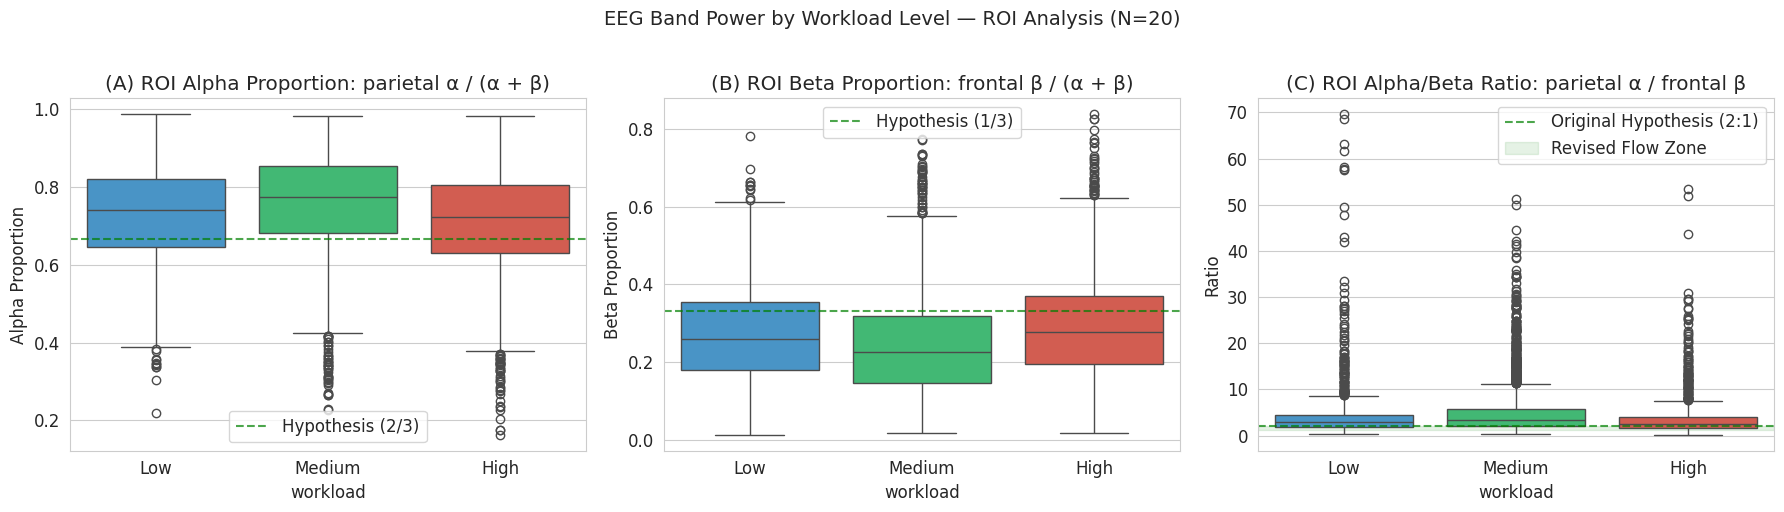

In [ ]:
# ---- Figure 1: ROI α/β by Workload (main result) ----

n_subjects = df_cog['subject'].nunique()
order = ['Low', 'Medium', 'High']
palette = {'Low': '#3498db', 'Medium': '#2ecc71', 'High': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A: ROI alpha proportion
sns.boxplot(data=df_cog, x='workload', y='roi_alpha_rel', order=order, palette=palette, ax=axes[0])
axes[0].axhline(y=0.667, color='green', linestyle='--', alpha=0.7, label='Hypothesis (2/3)')
axes[0].set_title('(A) ROI Alpha Proportion: parietal α / (α + β)')
axes[0].set_ylabel('Alpha Proportion')
axes[0].legend()

# B: ROI beta proportion
sns.boxplot(data=df_cog, x='workload', y='roi_beta_rel', order=order, palette=palette, ax=axes[1])
axes[1].axhline(y=0.333, color='green', linestyle='--', alpha=0.7, label='Hypothesis (1/3)')
axes[1].set_title('(B) ROI Beta Proportion: frontal β / (α + β)')
axes[1].set_ylabel('Beta Proportion')
axes[1].legend()

# C: ROI α/β ratio
sns.boxplot(data=df_cog, x='workload', y='roi_ab_ratio', order=order, palette=palette, ax=axes[2])
axes[2].axhline(y=2.0, color='green', linestyle='--', alpha=0.7, label='Original Hypothesis (2:1)')
axes[2].axhspan(1.2, 2.0, alpha=0.1, color='green', label='Revised Flow Zone')
axes[2].set_title('(C) ROI Alpha/Beta Ratio: parietal α / frontal β')
axes[2].set_ylabel('Ratio')
axes[2].legend()

plt.suptitle(f'EEG Band Power by Workload Level — ROI Analysis (N={n_subjects})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('v2_fig1_roi_ab_by_workload.png', dpi=150, bbox_inches='tight')
plt.show()

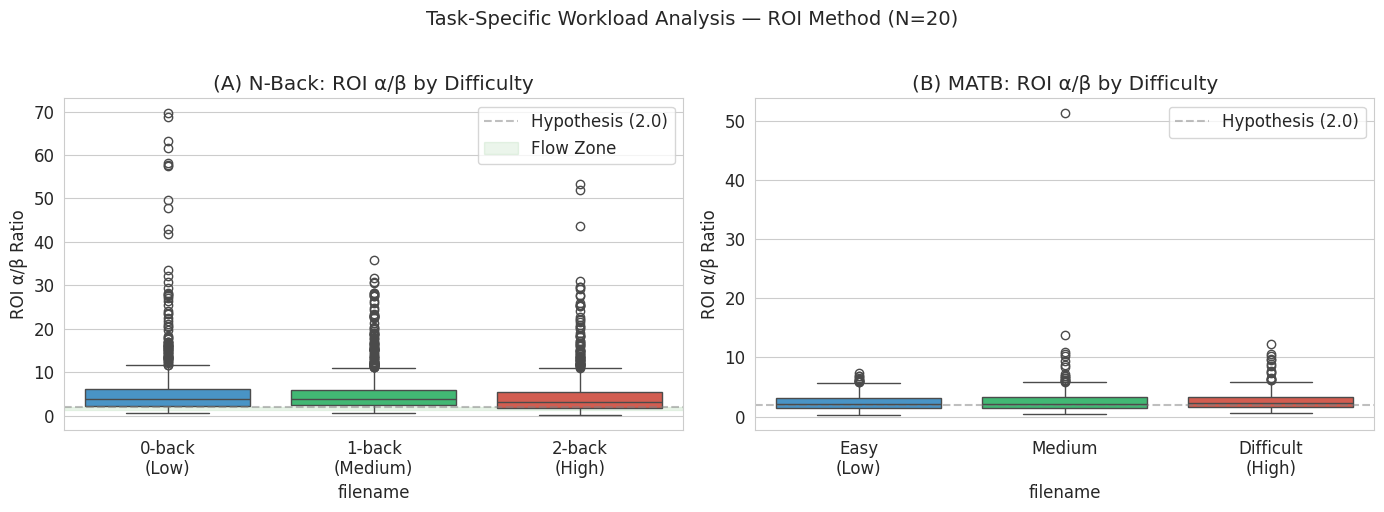

In [ ]:
# ---- Figure 2: N-Back and MATB task-specific ----

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# N-Back
nback = df[df['task'] == 'N-Back']
if len(nback) > 0:
    sns.boxplot(data=nback, x='filename', y='roi_ab_ratio',
                order=['zeroBACK', 'oneBACK', 'twoBACK'],
                palette=['#3498db', '#2ecc71', '#e74c3c'], ax=axes[0])
    axes[0].axhline(y=2.0, color='gray', linestyle='--', alpha=0.5, label='Hypothesis (2.0)')
    axes[0].axhspan(1.2, 2.0, alpha=0.08, color='green', label='Flow Zone')
    axes[0].set_title('(A) N-Back: ROI α/β by Difficulty')
    axes[0].set_xticklabels(['0-back\n(Low)', '1-back\n(Medium)', '2-back\n(High)'])
    axes[0].set_ylabel('ROI α/β Ratio')
    axes[0].legend()

# MATB
matb = df[df['task'] == 'MATB']
if len(matb) > 0:
    sns.boxplot(data=matb, x='filename', y='roi_ab_ratio',
                order=['MATBeasy', 'MATBmed', 'MATBdiff'],
                palette=['#3498db', '#2ecc71', '#e74c3c'], ax=axes[1])
    axes[1].axhline(y=2.0, color='gray', linestyle='--', alpha=0.5, label='Hypothesis (2.0)')
    axes[1].set_title('(B) MATB: ROI α/β by Difficulty')
    axes[1].set_xticklabels(['Easy\n(Low)', 'Medium', 'Difficult\n(High)'])
    axes[1].set_ylabel('ROI α/β Ratio')
    axes[1].legend()

plt.suptitle(f'Task-Specific Workload Analysis — ROI Method (N={n_subjects})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('v2_fig2_nback_matb.png', dpi=150, bbox_inches='tight')
plt.show()

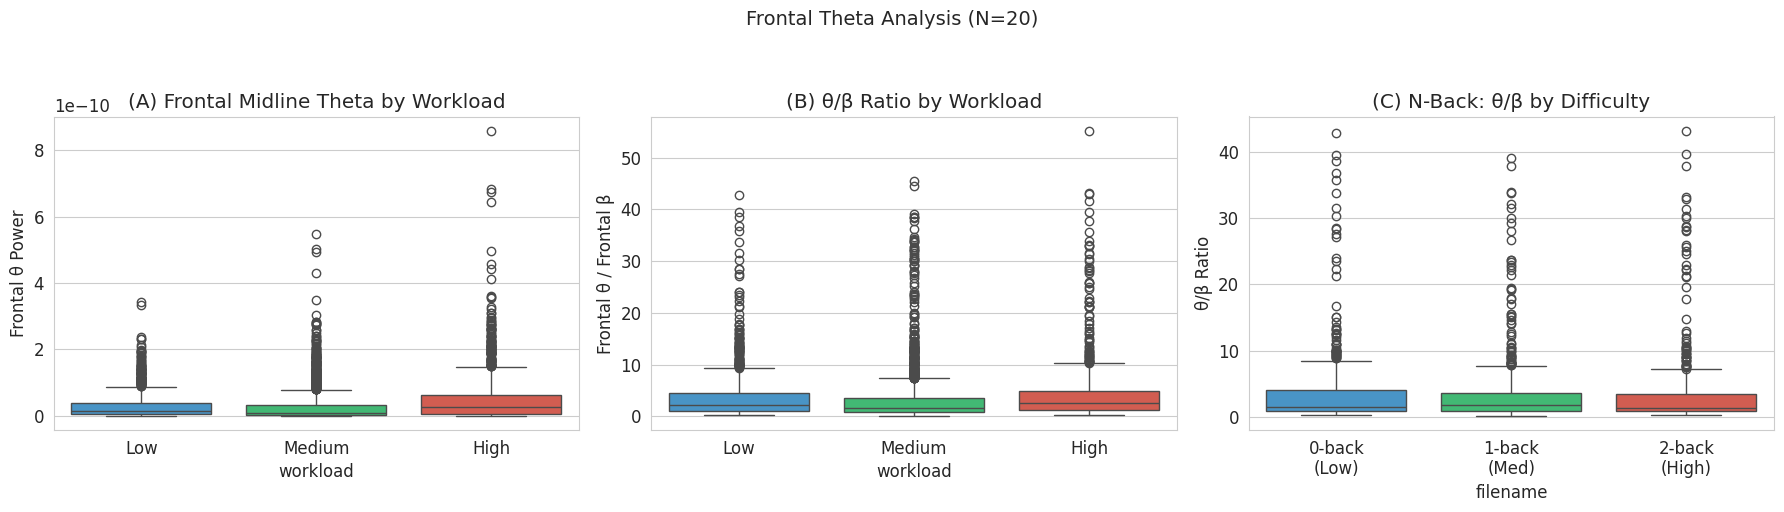

In [ ]:
# ---- Figure 3: Theta analysis (new!) ----

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A: Frontal theta by workload
sns.boxplot(data=df_cog, x='workload', y='frontal_theta', order=order, palette=palette, ax=axes[0])
axes[0].set_title('(A) Frontal Midline Theta by Workload')
axes[0].set_ylabel('Frontal θ Power')

# B: θ/β ratio by workload
sns.boxplot(data=df_cog, x='workload', y='theta_beta_ratio', order=order, palette=palette, ax=axes[1])
axes[1].set_title('(B) θ/β Ratio by Workload')
axes[1].set_ylabel('Frontal θ / Frontal β')

# C: θ/β for N-Back specifically
nback_cog = df[df['filename'].isin(['zeroBACK','oneBACK','twoBACK'])]
if len(nback_cog) > 0:
    sns.boxplot(data=nback_cog, x='filename', y='theta_beta_ratio',
                order=['zeroBACK','oneBACK','twoBACK'],
                palette=['#3498db','#2ecc71','#e74c3c'], ax=axes[2])
    axes[2].set_title('(C) N-Back: θ/β by Difficulty')
    axes[2].set_xticklabels(['0-back\n(Low)', '1-back\n(Med)', '2-back\n(High)'])
    axes[2].set_ylabel('θ/β Ratio')

plt.suptitle(f'Frontal Theta Analysis (N={n_subjects})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('v2_fig3_theta_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

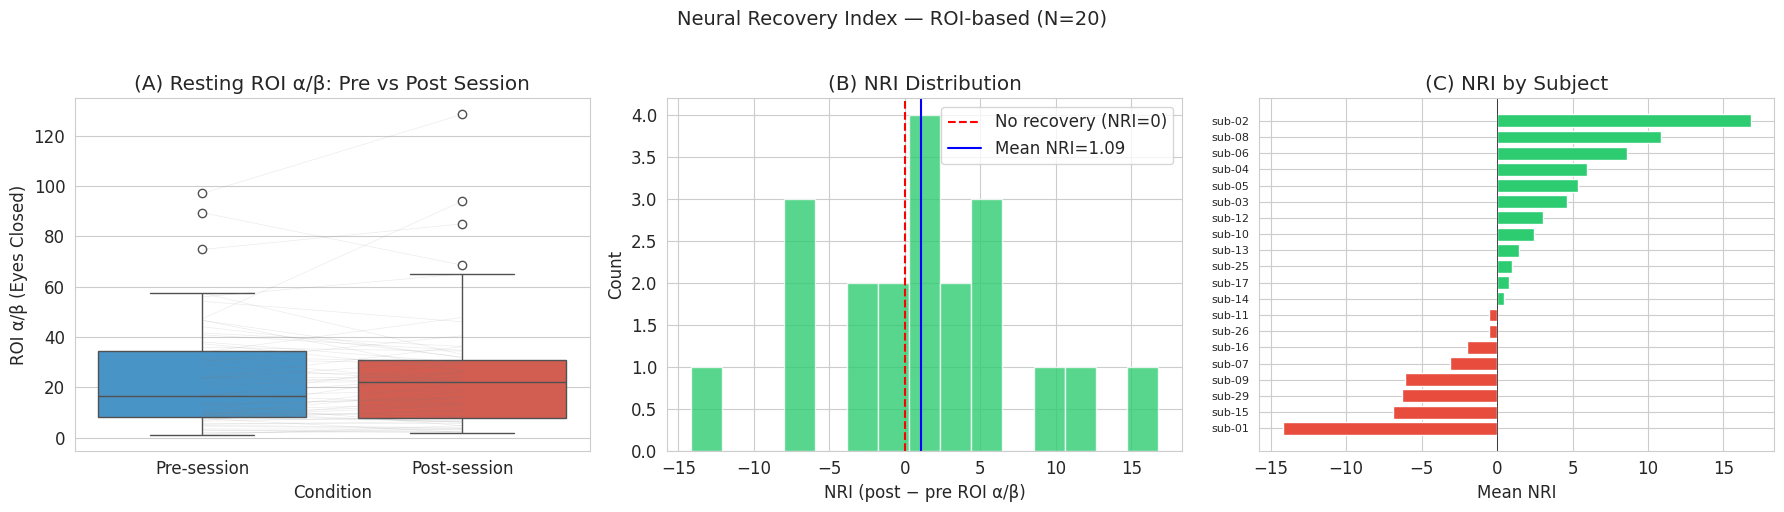

In [ ]:
# ---- Figure 4: NRI ----

if len(df_nri) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # A: Pre vs Post resting α/β
    pre_vals = df_nri['pre_ab_ratio']
    post_vals = df_nri['post_ab_ratio']
    bp_data = pd.DataFrame({
        'Condition': ['Pre-session']*len(pre_vals) + ['Post-session']*len(post_vals),
        'ROI α/β': list(pre_vals) + list(post_vals)
    })
    sns.boxplot(data=bp_data, x='Condition', y='ROI α/β',
                palette=['#3498db','#e74c3c'], ax=axes[0])
    # Connect paired observations
    for _, row in df_nri.iterrows():
        axes[0].plot([0, 1], [row['pre_ab_ratio'], row['post_ab_ratio']],
                     color='gray', alpha=0.15, linewidth=0.5)
    axes[0].set_title('(A) Resting ROI α/β: Pre vs Post Session')
    axes[0].set_ylabel('ROI α/β (Eyes Closed)')

    # B: NRI distribution
    axes[1].hist(nri_by_sub['nri_mean'], bins=15, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes[1].axvline(x=0, color='red', linestyle='--', label='No recovery (NRI=0)')
    axes[1].axvline(x=nri_by_sub['nri_mean'].mean(), color='blue', linestyle='-',
                     label=f'Mean NRI={nri_by_sub["nri_mean"].mean():.2f}')
    axes[1].set_title('(B) NRI Distribution')
    axes[1].set_xlabel('NRI (post − pre ROI α/β)')
    axes[1].set_ylabel('Count')
    axes[1].legend()

    # C: NRI by subject
    nri_sorted = nri_by_sub.sort_values('nri_mean')
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in nri_sorted['nri_mean']]
    axes[2].barh(range(len(nri_sorted)), nri_sorted['nri_mean'], color=colors)
    axes[2].set_yticks(range(len(nri_sorted)))
    axes[2].set_yticklabels(nri_sorted['subject'], fontsize=8)
    axes[2].axvline(x=0, color='black', linewidth=0.5)
    axes[2].set_title('(C) NRI by Subject')
    axes[2].set_xlabel('Mean NRI')

    plt.suptitle(f'Neural Recovery Index — ROI-based (N={n_subjects})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('v2_fig4_nri.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No NRI data to plot')

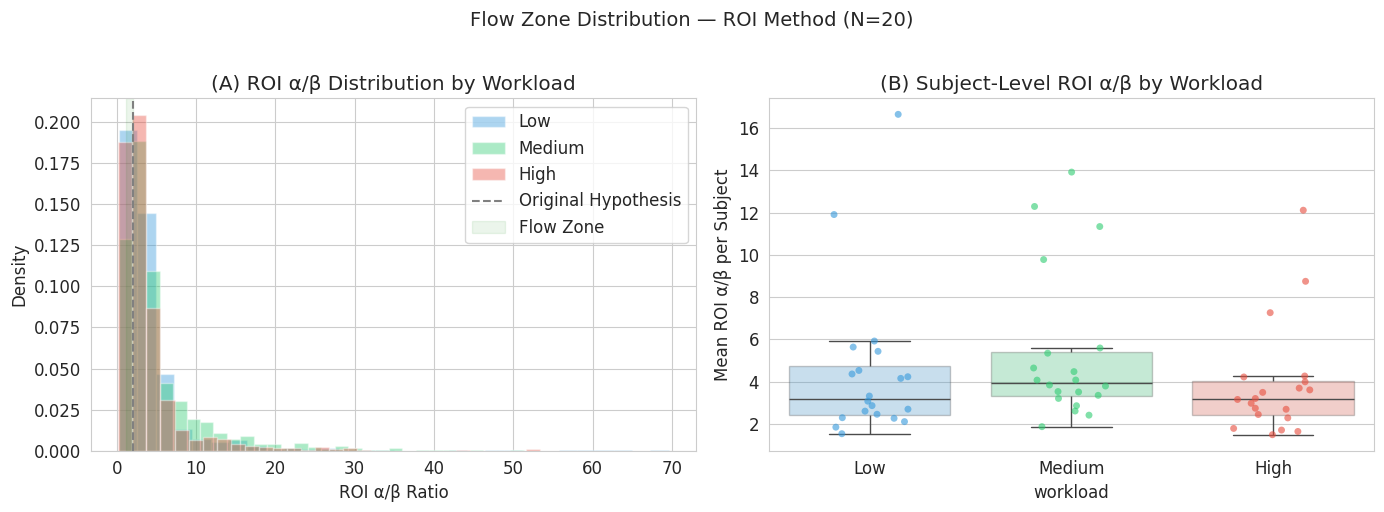

In [ ]:
# ---- Figure 5: ROI vs Global comparison ----

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A: Distribution comparison
for wl, color, label in zip(order, ['#3498db','#2ecc71','#e74c3c'],
                              ['Low','Medium','High']):
    data = df_cog[df_cog['workload']==wl]['roi_ab_ratio']
    axes[0].hist(data, bins=30, alpha=0.4, color=color, label=label, density=True)
axes[0].axhspan(0, 0, alpha=0)  # dummy
axes[0].axvline(x=2.0, color='gray', linestyle='--', label='Original Hypothesis')
axes[0].axvspan(1.2, 2.0, alpha=0.08, color='green', label='Flow Zone')
axes[0].set_title('(A) ROI α/β Distribution by Workload')
axes[0].set_xlabel('ROI α/β Ratio')
axes[0].set_ylabel('Density')
axes[0].legend()

# B: Inter-subject variability
sub_means = df_cog.groupby(['subject','workload'])['roi_ab_ratio'].mean().reset_index()
sns.stripplot(data=sub_means, x='workload', y='roi_ab_ratio', order=order,
              palette=palette, alpha=0.6, jitter=0.2, ax=axes[1])
sns.boxplot(data=sub_means, x='workload', y='roi_ab_ratio', order=order,
            palette=palette, boxprops=dict(alpha=0.3), ax=axes[1], fliersize=0)
axes[1].set_title('(B) Subject-Level ROI α/β by Workload')
axes[1].set_ylabel('Mean ROI α/β per Subject')

plt.suptitle(f'Flow Zone Distribution — ROI Method (N={n_subjects})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('v2_fig5_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

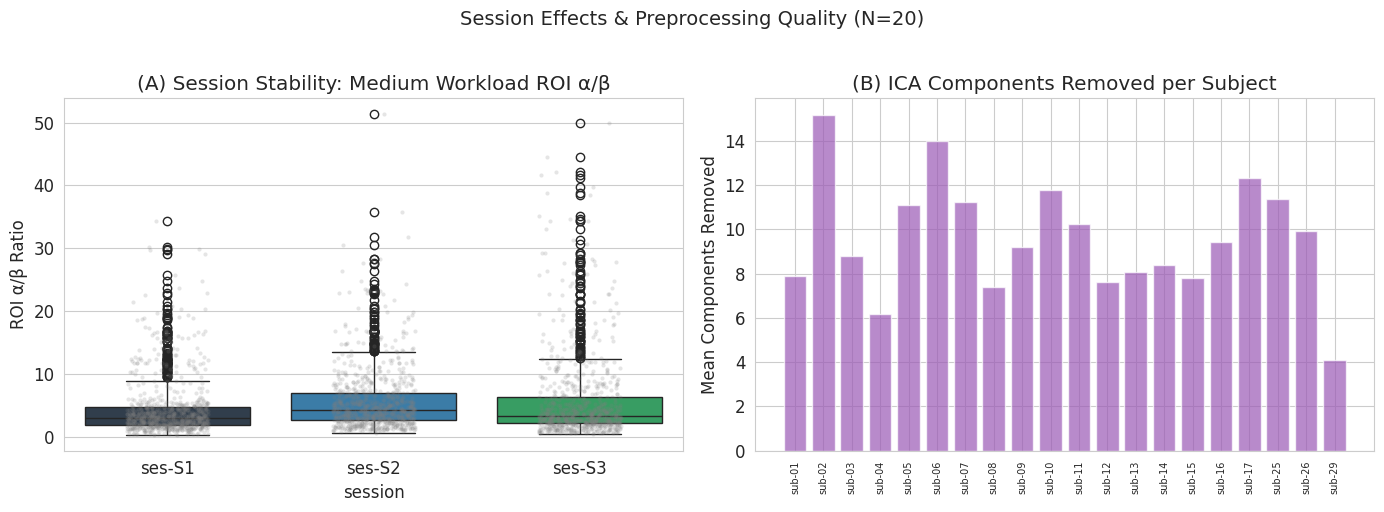

In [ ]:
# ---- Figure 6: Session stability ----

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A: Medium workload α/β across sessions
df_med = df_cog[df_cog['workload'] == 'Medium']
if len(df_med) > 0:
    sns.boxplot(data=df_med, x='session', y='roi_ab_ratio',
                order=['ses-S1','ses-S2','ses-S3'],
                palette=['#2c3e50','#2980b9','#27ae60'], ax=axes[0])
    sns.stripplot(data=df_med, x='session', y='roi_ab_ratio',
                  order=['ses-S1','ses-S2','ses-S3'],
                  color='gray', alpha=0.2, jitter=0.2, ax=axes[0], size=3)
    axes[0].set_title('(A) Session Stability: Medium Workload ROI α/β')
    axes[0].set_ylabel('ROI α/β Ratio')

# B: ICA components removed per subject
ica_stats = df.groupby('subject')['ica_components_removed'].mean().reset_index()
axes[1].bar(range(len(ica_stats)), ica_stats['ica_components_removed'].values,
            color='#9b59b6', alpha=0.7)
axes[1].set_xticks(range(len(ica_stats)))
axes[1].set_xticklabels(ica_stats['subject'].values, rotation=90, fontsize=7)
axes[1].set_title('(B) ICA Components Removed per Subject')
axes[1].set_ylabel('Mean Components Removed')

plt.suptitle(f'Session Effects & Preprocessing Quality (N={n_subjects})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('v2_fig6_session_ica.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: Grand Summary

In [ ]:
# Save grand summary
summary = df_cog.groupby('workload').agg(
    n_epochs=('roi_ab_ratio', 'count'),
    n_subjects=('subject', 'nunique'),
    roi_ab_mean=('roi_ab_ratio', 'mean'),
    roi_ab_std=('roi_ab_ratio', 'std'),
    global_ab_mean=('global_ab_ratio', 'mean'),
    global_ab_std=('global_ab_ratio', 'std'),
    tb_mean=('theta_beta_ratio', 'mean'),
    tb_std=('theta_beta_ratio', 'std'),
    frontal_theta_mean=('frontal_theta', 'mean'),
    parietal_alpha_mean=('parietal_alpha', 'mean'),
    frontal_beta_mean=('frontal_beta', 'mean'),
).round(6)

summary.to_csv('v2_grand_summary.csv')
print('Grand summary:')
print(summary.to_string())

# Subject-level summary
sub_summary = df_cog.groupby(['subject', 'workload']).agg(
    roi_ab=('roi_ab_ratio', 'mean'),
    theta_beta=('theta_beta_ratio', 'mean'),
    frontal_theta=('frontal_theta', 'mean'),
    n_epochs=('roi_ab_ratio', 'count')
).reset_index().round(6)

sub_summary.to_csv('v2_subject_workload_summary.csv', index=False)
print(f'\nSaved v2_grand_summary.csv and v2_subject_workload_summary.csv')

print(f'\n{"="*60}')
print(f'ALL DONE! Files saved:')
print(f'{"="*60}')
for f in ['v2_all_epochs.csv', 'v2_all_resting.csv', 'v2_processing_log.csv',
          'v2_nri_sessions.csv', 'v2_nri_by_subject.csv',
          'v2_grand_summary.csv', 'v2_subject_workload_summary.csv']:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f'  {f}: {size:.0f} KB')

Grand summary:
          n_epochs  n_subjects  roi_ab_mean  roi_ab_std  global_ab_mean  global_ab_std   tb_mean    tb_std  frontal_theta_mean  parietal_alpha_mean  frontal_beta_mean
workload                                                                                                                                                              
High          1188          20     3.893428    4.646541        1.266267       1.007266  4.046481  5.416501                 0.0                  0.0                0.0
Low           1165          20     4.494827    6.588463        1.335521       1.183751  3.705977  4.698604                 0.0                  0.0                0.0
Medium        2383          20     5.327980    5.724732        1.475270       1.313955  3.218795  4.926600                 0.0                  0.0                0.0

Saved v2_grand_summary.csv and v2_subject_workload_summary.csv

ALL DONE! Files saved:
  v2_all_epochs.csv: 2437 KB
  v2_all_resting.csv: 182 KB
  v2